In [46]:
#  : IMPORT LIBRARIES

# Pandas is used for reading and analyzing data
import pandas as pd

# NumPy is used for numerical calculations
import numpy as np

# Matplotlib is used for creating charts
import matplotlib.pyplot as plt

# Seaborn is used for advanced visualizations
import seaborn as sns

# Display all columns while viewing data
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [47]:
#  LOAD THE DATASET

# Read the CSV file
# keep_default_na=False ensures that "None" remains a valid value
# and is not treated as a missing value

df = pd.read_csv(
    "../data/hotel_bookings (1).csv",
    keep_default_na=False
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [48]:
#  DATASET SHAPE

# Number of Rows and Columns

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(12000, 28)


In [49]:
"""
Observation:

1. The dataset contains hotel booking transaction records.

2. Each row represents a unique booking.

3. Each column represents a different attribute such as
   customer information, booking details, property details,
   revenue, reviews, and loyalty information.

4. The dataset appears sufficiently large for meaningful
   business analysis.
"""

'\nObservation:\n\n1. The dataset contains hotel booking transaction records.\n\n2. Each row represents a unique booking.\n\n3. Each column represents a different attribute such as\n   customer information, booking details, property details,\n   revenue, reviews, and loyalty information.\n\n4. The dataset appears sufficiently large for meaningful\n   business analysis.\n'

In [50]:
# VIEW COLUMN NAMES

print("Columns Available:")
print(df.columns.tolist())

Columns Available:
['booking_id', 'customer_id', 'customer_name', 'customer_segment', 'customer_signup_date', 'customer_home_city', 'customer_loyalty_tier', 'property_id', 'property_name', 'property_city', 'property_star_rating', 'property_type', 'property_total_rooms', 'booking_date', 'checkin_date', 'checkout_date', 'room_type', 'num_rooms', 'nights', 'booking_channel', 'adr', 'discount_amount', 'coupon_code', 'total_amount', 'payment_method', 'booking_status', 'review_rating', 'review_date']


In [51]:
#  FIRST FIVE RECORDS

df.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,3,Mid-Range,40,2024-06-01,2024-08-30,2024-09-03,Deluxe,2,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,,
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,5,Mid-Range,30,2024-06-06,2024-07-01,2024-07-05,Standard,1,4,Corporate Portal,4021.62,0.00,,16086.48,Net Banking,Cancelled,,
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,3,Luxury,150,2024-02-15,2024-02-22,2024-02-25,Deluxe,2,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,3,Mid-Range,100,2024-07-10,2024-08-04,2024-08-07,Deluxe,1,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,,
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,5,Mid-Range,60,2024-10-27,2024-11-11,2024-11-18,Deluxe,2,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


In [52]:
#  DATA TYPES

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             12000 non-null  int64  
 1   customer_id            12000 non-null  int64  
 2   customer_name          12000 non-null  str    
 3   customer_segment       12000 non-null  str    
 4   customer_signup_date   12000 non-null  str    
 5   customer_home_city     12000 non-null  str    
 6   customer_loyalty_tier  12000 non-null  str    
 7   property_id            12000 non-null  int64  
 8   property_name          12000 non-null  str    
 9   property_city          12000 non-null  str    
 10  property_star_rating   12000 non-null  int64  
 11  property_type          12000 non-null  str    
 12  property_total_rooms   12000 non-null  int64  
 13  booking_date           12000 non-null  str    
 14  checkin_date           12000 non-null  str    
 15  checkout_date

In [53]:
# ============================================================
# CONVERT DATE COLUMNS
# ============================================================

# These columns contain dates but are currently stored as text

date_columns = [
    'customer_signup_date',
    'booking_date',
    'checkin_date',
    'checkout_date',
    'review_date'
]

# Convert each column into proper datetime format

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce'
    )

print("Date Conversion Completed")

Date Conversion Completed


In [54]:
# ============================================================
# VERIFY DATE CONVERSION
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   booking_id             12000 non-null  int64         
 1   customer_id            12000 non-null  int64         
 2   customer_name          12000 non-null  str           
 3   customer_segment       12000 non-null  str           
 4   customer_signup_date   12000 non-null  datetime64[us]
 5   customer_home_city     12000 non-null  str           
 6   customer_loyalty_tier  12000 non-null  str           
 7   property_id            12000 non-null  int64         
 8   property_name          12000 non-null  str           
 9   property_city          12000 non-null  str           
 10  property_star_rating   12000 non-null  int64         
 11  property_type          12000 non-null  str           
 12  property_total_rooms   12000 non-null  int64         
 13  booking_date

In [55]:
# ============================================================
# FOOTNOTE 1 : INVALID STAY CHECK
# ============================================================

# Finding records where checkout date is
# earlier than or equal to checkin date

invalid_stays = df[
    df['checkout_date']
    <=
    df['checkin_date']
]

print("Invalid Stay Records Found:")
print(len(invalid_stays))

Invalid Stay Records Found:
120


In [56]:
invalid_stays.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
151,100151,439,Customer_439,Individual,2023-12-13,Delhi,Gold,25,Tusker Stay,Pune,2,Mid-Range,60,2024-11-28,2024-12-13,2024-12-13,Standard,1,4,Travel Agent,3870.62,0.00,NONE,15482.48,UPI,Completed,4.0,2024-12-20
172,100172,288,Customer_288,Individual,2022-10-22,Kochi,None,13,Tusker Palace,Goa,5,Mid-Range,80,2024-08-02,2024-08-09,2024-08-08,Deluxe,1,2,Direct Website,5195.17,0.00,,10390.34,Debit Card,Completed,,NaT
245,100245,512,Customer_512,Individual,2022-09-01,Mumbai,None,60,Amber Suites,Pune,2,Luxury,150,2024-09-23,2024-09-30,2024-09-29,Deluxe,1,3,OTA,17514.44,9638.16,SAVE10,42905.16,Debit Card,Completed,,NaT
264,100264,720,Customer_720,Individual,2023-07-09,Manali,None,10,Lotus Manor,Manali,4,Mid-Range,150,2024-11-15,2024-11-22,2024-11-22,Suite,1,2,OTA,8193.39,3716.72,FEST15,12670.06,Credit Card,Completed,,NaT
375,100375,670,Customer_670,Individual,2023-10-06,Jaipur,None,4,Sea Breeze Resort,Goa,4,Mid-Range,80,2024-05-04,2024-05-19,2024-05-19,Standard,1,1,Travel Agent,6150.64,984.68,FEST15,5165.96,Credit Card,Completed,4.0,2024-05-22


In [57]:
"""
============================================================
OBSERVATION - INVALID STAY CHECK
============================================================

1. A total of 120 booking records were found where
   checkout_date is less than or equal to checkin_date.

2. These records represent invalid stay durations and
   are likely caused by data entry mistakes or system errors.

3. Invalid stay records account for approximately 1%
   of the total dataset.

4. Such records can negatively impact occupancy analysis,
   stay duration calculations, and revenue reporting.

5. These records should be flagged and excluded from
   stay-based analysis.
"""

'\n============================================================\nOBSERVATION - INVALID STAY CHECK\n============================================================\n\n1. A total of 120 booking records were found where\n   checkout_date is less than or equal to checkin_date.\n\n2. These records represent invalid stay durations and\n   are likely caused by data entry mistakes or system errors.\n\n3. Invalid stay records account for approximately 1%\n   of the total dataset.\n\n4. Such records can negatively impact occupancy analysis,\n   stay duration calculations, and revenue reporting.\n\n5. These records should be flagged and excluded from\n   stay-based analysis.\n'

In [58]:
# ============================================================
# FOOTNOTE 2 : BOOKING BEFORE SIGNUP CHECK
# ============================================================

booking_before_signup = df[
    df['booking_date']
    <
    df['customer_signup_date']
]

print("Booking Before Signup Records Found:")
print(len(booking_before_signup))

Booking Before Signup Records Found:
163


In [59]:
booking_before_signup.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
73,100073,1,Customer_1,Individual,2022-02-04,Jaipur,Silver,46,Coral Manor,Kochi,4,Budget,80,2021-10-22,2024-05-25,2024-05-26,Standard,1,1,Corporate Portal,2044.52,0.00,,2044.52,Net Banking,Cancelled,,NaT
154,100154,145,Customer_145,Group,2023-10-17,Delhi,Platinum,43,Indigo Lodge,Bangalore,3,Mid-Range,100,2023-10-06,2024-01-04,2024-01-05,Standard,2,1,Corporate Portal,4284.20,0.00,,8568.40,Net Banking,Cancelled,,NaT
296,100296,565,Customer_565,Corporate,2023-11-17,Manali,Silver,35,Maple Retreat,Bangalore,2,Premium,100,2023-11-03,2024-07-20,2024-07-25,Standard,1,5,Corporate Portal,9124.74,0.00,NONE,45623.70,Net Banking,Completed,,NaT
361,100361,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,9,Crimson Retreat,Udaipur,5,Mid-Range,80,2023-11-06,2024-01-07,2024-01-10,Suite,2,3,Corporate Portal,15764.96,0.00,NONE,94589.76,UPI,Completed,4.0,2024-01-11
420,100420,293,Customer_293,Individual,2022-07-09,Delhi,Silver,8,Royal Orchid,Goa,5,Luxury,120,2022-03-23,2024-05-28,2024-05-29,Standard,1,1,OTA,20940.76,5737.72,APPDEAL,15203.04,Net Banking,Completed,5.0,2024-06-11


In [60]:
len(booking_before_signup)

163

In [61]:
booking_before_signup.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
73,100073,1,Customer_1,Individual,2022-02-04,Jaipur,Silver,46,Coral Manor,Kochi,4,Budget,80,2021-10-22,2024-05-25,2024-05-26,Standard,1,1,Corporate Portal,2044.52,0.00,,2044.52,Net Banking,Cancelled,,NaT
154,100154,145,Customer_145,Group,2023-10-17,Delhi,Platinum,43,Indigo Lodge,Bangalore,3,Mid-Range,100,2023-10-06,2024-01-04,2024-01-05,Standard,2,1,Corporate Portal,4284.20,0.00,,8568.40,Net Banking,Cancelled,,NaT
296,100296,565,Customer_565,Corporate,2023-11-17,Manali,Silver,35,Maple Retreat,Bangalore,2,Premium,100,2023-11-03,2024-07-20,2024-07-25,Standard,1,5,Corporate Portal,9124.74,0.00,NONE,45623.70,Net Banking,Completed,,NaT
361,100361,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,9,Crimson Retreat,Udaipur,5,Mid-Range,80,2023-11-06,2024-01-07,2024-01-10,Suite,2,3,Corporate Portal,15764.96,0.00,NONE,94589.76,UPI,Completed,4.0,2024-01-11
420,100420,293,Customer_293,Individual,2022-07-09,Delhi,Silver,8,Royal Orchid,Goa,5,Luxury,120,2022-03-23,2024-05-28,2024-05-29,Standard,1,1,OTA,20940.76,5737.72,APPDEAL,15203.04,Net Banking,Completed,5.0,2024-06-11


In [62]:
# ============================================================
# FOOTNOTE 3 : ZERO ROOM BOOKING CHECK
# ============================================================

# Checking bookings where number of rooms booked is zero

zero_rooms = df[
    df['num_rooms'] == 0
]

print("Bookings With Zero Rooms:")
print(len(zero_rooms))

Bookings With Zero Rooms:
60


In [63]:
zero_rooms.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
55,100055,723,Customer_723,Individual,2023-01-06,Goa,None,16,Banyan Residency,Delhi,3,Budget,60,2024-04-22,2024-05-07,2024-05-10,Standard,0,3,OTA,2505.28,960.13,WELCOME,0.0,Debit Card,Completed,,NaT
101,100101,73,Customer_73,Group,2023-07-08,Chennai,None,40,Mango Lodge,Bangalore,3,Mid-Range,40,2024-05-22,2024-05-29,2024-05-31,Suite,0,2,Corporate Portal,9289.49,0.00,NONE,0.0,Debit Card,Completed,5.0,2024-06-14
372,100372,657,Customer_657,Individual,2023-12-08,Jaipur,Silver,7,Royal Orchid,Chennai,4,Budget,80,2024-04-05,2024-04-30,2024-05-01,Standard,0,1,OTA,2369.62,0.00,,0.0,Net Banking,Cancelled,,NaT
385,100385,13,Customer_13,Individual,2023-11-25,Chennai,Silver,35,Maple Retreat,Bangalore,2,Premium,100,2024-05-01,2024-05-16,2024-05-17,Standard,0,1,Travel Agent,8848.19,0.00,,0.0,UPI,Completed,5.0,2024-05-24
403,100403,447,Customer_447,Individual,2022-02-19,Kochi,Platinum,27,Saffron Residency,Pune,3,Mid-Range,80,2024-02-29,2024-04-29,2024-05-02,Deluxe,0,3,Travel Agent,5306.07,0.00,NONE,0.0,UPI,Cancelled,,NaT


In [64]:
"""
============================================================
OBSERVATION - ZERO ROOM BOOKING CHECK
============================================================

1. A total of 60 booking records were found where
   the number of rooms booked is equal to zero.

2. A booking should normally contain at least one room,
   making these records logically invalid.

3. These records may have been generated due to
   incomplete transactions, system errors,
   or incorrect data entry.

4. Zero-room bookings can impact occupancy reporting,
   demand forecasting, and booking conversion analysis.

5. These records should be flagged and excluded from
   room-based business calculations.
"""

'\n============================================================\nOBSERVATION - ZERO ROOM BOOKING CHECK\n============================================================\n\n1. A total of 60 booking records were found where\n   the number of rooms booked is equal to zero.\n\n2. A booking should normally contain at least one room,\n   making these records logically invalid.\n\n3. These records may have been generated due to\n   incomplete transactions, system errors,\n   or incorrect data entry.\n\n4. Zero-room bookings can impact occupancy reporting,\n   demand forecasting, and booking conversion analysis.\n\n5. These records should be flagged and excluded from\n   room-based business calculations.\n'

In [65]:
# ============================================================
# FOOTNOTE 4 : REVIEWS ON CANCELLED BOOKINGS
# ============================================================

# Finding cancelled bookings that still have reviews

cancelled_reviews = df[
    (df['booking_status'] == 'Cancelled')
    &
    (df['review_rating'] != '')
]

print("Cancelled Bookings With Reviews:")
print(len(cancelled_reviews))

Cancelled Bookings With Reviews:
50


In [66]:
cancelled_reviews.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,property_star_rating,property_type,property_total_rooms,booking_date,checkin_date,checkout_date,room_type,num_rooms,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
131,100131,565,Customer_565,Corporate,2023-11-17,Manali,Silver,48,Amber Manor,Chennai,3,Premium,100,2024-06-01,2024-06-16,2024-06-18,Standard,2,2,Corporate Portal,8874.45,0.00,,35497.80,Credit Card,Cancelled,9.0,2024-07-01
925,100925,229,Customer_229,Individual,2022-07-09,Bangalore,Silver,17,Indigo Palace,Udaipur,3,Budget,100,2024-04-06,2024-07-05,2024-07-09,Standard,1,4,OTA,3012.18,2136.49,FEST15,9912.23,Credit Card,Cancelled,4.0,2024-07-09
955,100955,770,Customer_770,Corporate,2023-10-05,Manali,Silver,19,Marigold Palace,Delhi,4,Mid-Range,60,2023-12-06,2024-01-15,2024-01-17,Standard,2,2,Corporate Portal,5528.25,1627.54,SAVE10,20485.46,Debit Card,Cancelled,10.0,2024-02-14
1314,101314,307,Customer_307,Individual,2022-11-20,Goa,Gold,7,Royal Orchid,Chennai,4,Budget,80,2024-10-09,2024-11-03,2024-11-06,Standard,1,3,OTA,2480.75,0.00,NONE,7442.25,Net Banking,Cancelled,4.0,2024-11-16
1349,101349,348,Customer_348,Corporate,2023-09-26,Kochi,None,13,Tusker Palace,Goa,5,Mid-Range,80,2024-04-22,2024-06-01,2024-06-05,Standard,1,4,Corporate Portal,4407.45,1970.15,SAVE10,15659.65,Credit Card,Cancelled,8.0,2024-06-26


In [67]:
"""
============================================================
OBSERVATION - REVIEWS ON CANCELLED BOOKINGS
============================================================

1. A total of 50 cancelled bookings were found
   with associated customer reviews.

2. Under normal circumstances, cancelled bookings
   should not receive reviews because the stay
   was never completed.

3. These records may indicate review mapping issues,
   delayed cancellations, or data inconsistencies.

4. Such records can affect customer satisfaction
   analysis and hotel performance evaluation.

5. These records should be validated before using
   review data for business decision-making.
"""

'\n============================================================\nOBSERVATION - REVIEWS ON CANCELLED BOOKINGS\n============================================================\n\n1. A total of 50 cancelled bookings were found\n   with associated customer reviews.\n\n2. Under normal circumstances, cancelled bookings\n   should not receive reviews because the stay\n   was never completed.\n\n3. These records may indicate review mapping issues,\n   delayed cancellations, or data inconsistencies.\n\n4. Such records can affect customer satisfaction\n   analysis and hotel performance evaluation.\n\n5. These records should be validated before using\n   review data for business decision-making.\n'

In [68]:
# ============================================================
# FOOTNOTE 5 : REVIEW DATA ANALYSIS
# ============================================================

print("Missing Review Ratings:")
print(df['review_rating'].isna().sum())

print("\nMissing Review Dates:")
print(df['review_date'].isna().sum())

Missing Review Ratings:
0

Missing Review Dates:
6854


In [69]:
"""
============================================================
OBSERVATION - REVIEW DATA ANALYSIS
============================================================

1. No missing values were found in the review_rating field.

2. A total of 6854 records were found with missing review dates.

3. Missing review dates are expected because not every
   customer leaves feedback after their stay.

4. The large number of missing review dates suggests
   that customer review participation is relatively low.

5. Any analysis based on reviews should consider only
   records where review information is available.
"""

'\n============================================================\nOBSERVATION - REVIEW DATA ANALYSIS\n============================================================\n\n1. No missing values were found in the review_rating field.\n\n2. A total of 6854 records were found with missing review dates.\n\n3. Missing review dates are expected because not every\n   customer leaves feedback after their stay.\n\n4. The large number of missing review dates suggests\n   that customer review participation is relatively low.\n\n5. Any analysis based on reviews should consider only\n   records where review information is available.\n'

In [70]:
# ============================================================
# REVIEW RATING VALIDATION
# ============================================================

print("Unique Review Ratings:")
print(df['review_rating'].unique())

Unique Review Ratings:
<StringArray>
['', '6.0', '3.0', '2.0', '5.0', '4.0', '1.0', '9.0', '7.0', '10.0', '8.0']
Length: 11, dtype: str


In [71]:
"""
============================================================
OBSERVATION - REVIEW RATING VALIDATION
============================================================

1. Review ratings are stored as text values.

2. The rating scale ranges from 1 to 10.

3. Blank values are represented as empty strings
   rather than missing (NaN) values.

4. This approach explains why no missing values
   were detected in the review_rating column.

5. Any review analysis should exclude blank ratings
   before calculating average customer satisfaction.
"""

'\n============================================================\nOBSERVATION - REVIEW RATING VALIDATION\n============================================================\n\n1. Review ratings are stored as text values.\n\n2. The rating scale ranges from 1 to 10.\n\n3. Blank values are represented as empty strings\n   rather than missing (NaN) values.\n\n4. This approach explains why no missing values\n   were detected in the review_rating column.\n\n5. Any review analysis should exclude blank ratings\n   before calculating average customer satisfaction.\n'

In [72]:
# ============================================================
# DUPLICATE BOOKING ID CHECK
# ============================================================

duplicate_bookings = df[
    df.duplicated(
        subset=['booking_id'],
        keep=False
    )
]

print("Duplicate Booking IDs:")
print(len(duplicate_bookings))

Duplicate Booking IDs:
0


In [73]:
"""
============================================================
OBSERVATION - DUPLICATE BOOKING ID CHECK
============================================================

1. No duplicate booking IDs were found in the dataset.

2. Each booking record appears to have a unique
   booking identifier.

3. This indicates good data integrity for booking
   transactions.

4. Revenue and booking volume calculations are not
   affected by duplicate booking records.

5. No corrective action is required for booking IDs.
"""

'\n============================================================\nOBSERVATION - DUPLICATE BOOKING ID CHECK\n============================================================\n\n1. No duplicate booking IDs were found in the dataset.\n\n2. Each booking record appears to have a unique\n   booking identifier.\n\n3. This indicates good data integrity for booking\n   transactions.\n\n4. Revenue and booking volume calculations are not\n   affected by duplicate booking records.\n\n5. No corrective action is required for booking IDs.\n'

In [74]:
# ============================================================
# DUPLICATE CUSTOMER CHECK
# ============================================================

duplicate_customers = df[
    df.duplicated(
        subset=['customer_id'],
        keep=False
    )
]

print("Duplicate Customer Records:")
print(len(duplicate_customers))

Duplicate Customer Records:
12000


In [75]:
print("Unique Properties:")
print(df['property_id'].nunique())

Unique Properties:
60


In [76]:
print("Total Rows:", len(df))
print("Unique Customers:", df['customer_id'].nunique())

Total Rows: 12000
Unique Customers: 800


In [77]:
print(df['customer_id'].nunique())

800


In [78]:
"""
============================================================
OBSERVATION - CUSTOMER BASE ANALYSIS
============================================================

1. The dataset contains 12,000 booking transactions.

2. These bookings were made by 800 unique customers.

3. This indicates that customers have made multiple bookings
   over time.

4. The dataset is suitable for customer retention and loyalty
   analysis.

5. A total of 60 unique hotel properties are present,
   allowing property-level performance comparisons.

6. Repeat customer behavior can be analyzed to identify
   high-value customers and improve retention strategies.
"""

'\n============================================================\nOBSERVATION - CUSTOMER BASE ANALYSIS\n============================================================\n\n1. The dataset contains 12,000 booking transactions.\n\n2. These bookings were made by 800 unique customers.\n\n3. This indicates that customers have made multiple bookings\n   over time.\n\n4. The dataset is suitable for customer retention and loyalty\n   analysis.\n\n5. A total of 60 unique hotel properties are present,\n   allowing property-level performance comparisons.\n\n6. Repeat customer behavior can be analyzed to identify\n   high-value customers and improve retention strategies.\n'

In [79]:
# ============================================================
# DATA QUALITY SCORECARD
# ============================================================

quality_summary = {
    "Invalid Stay Records": len(invalid_stays),
    "Bookings Before Signup": len(booking_before_signup),
    "Zero Room Bookings": len(zero_rooms),
    "Cancelled Bookings With Reviews": len(cancelled_reviews),
    "Duplicate Booking IDs": len(duplicate_bookings)
}

quality_df = pd.DataFrame(
    quality_summary.items(),
    columns=["Issue", "Count"]
)

quality_df

,Issue,Count
0,Invalid Stay Records,120
1,Bookings Before Signup,163
2,Zero Room Bookings,60
3,Cancelled Bookings With Reviews,50
4,Duplicate Booking IDs,0


In [80]:
total_records = len(df)

print("Invalid Stay %:",
      round((len(invalid_stays)/total_records)*100,2))

print("Booking Before Signup %:",
      round((len(booking_before_signup)/total_records)*100,2))

print("Zero Room Booking %:",
      round((len(zero_rooms)/total_records)*100,2))

Invalid Stay %: 1.0
Booking Before Signup %: 1.36
Zero Room Booking %: 0.5


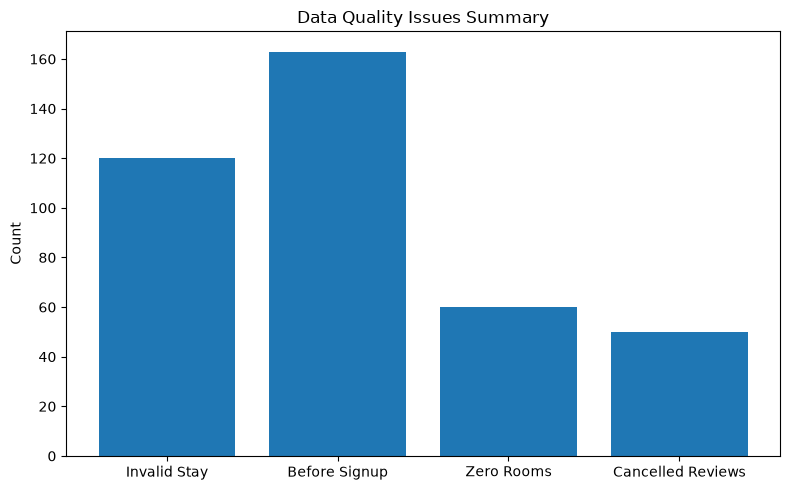

In [81]:
issues = [
    "Invalid Stay",
    "Before Signup",
    "Zero Rooms",
    "Cancelled Reviews"
]

counts = [
    len(invalid_stays),
    len(booking_before_signup),
    len(zero_rooms),
    len(cancelled_reviews)
]

plt.figure(figsize=(8,5))
plt.bar(issues, counts)

plt.title("Data Quality Issues Summary")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../outputs/charts/data_quality_summary.png")

plt.show()

In [82]:
print("""
EXECUTIVE SUMMARY

Dataset Size: 12,000 bookings

Unique Customers: 800

Unique Properties: 60

Data quality assessment identified a limited number of anomalies including invalid stay durations, bookings before signup dates, zero-room bookings, and cancelled bookings containing reviews.

No duplicate booking IDs were found, indicating strong transaction-level integrity.

Overall, the dataset is suitable for advanced business analysis after minor data validation and cleaning.
""")


EXECUTIVE SUMMARY

Dataset Size: 12,000 bookings

Unique Customers: 800

Unique Properties: 60

Data quality assessment identified a limited number of anomalies including invalid stay durations, bookings before signup dates, zero-room bookings, and cancelled bookings containing reviews.

No duplicate booking IDs were found, indicating strong transaction-level integrity.

Overall, the dataset is suitable for advanced business analysis after minor data validation and cleaning.

